# Введение и цель
## 📊 Сравнительный анализ классических моделей машинного обучения для фильтрации спама
**Цель:** Построить модель решающих деревьев при помощи CatBoost для классификации текстовых сообщений, оценить эффективность, зафиксировать метрики и сравнить их с моделью логистической регрессии, рассмотренной в предыдущем блокноте (01_logreg_model.ipynb).

In [3]:
!pip install catboost datasets scikit-learn pandas

^C


In [ ]:
import pandas as pd
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from huggingface_hub import notebook_login, login

notebook_login()

In [ ]:
dataset = load_dataset("ruSpamModels/russian-spam-detection", split='train')

README.md:   0%|          | 0.00/744 [00:00<?, ?B/s]

processed_combined.parquet:   0%|          | 0.00/480M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/4511513 [00:00<?, ? examples/s]

In [ ]:
df = pd.DataFrame(dataset)

In [ ]:
# Отбираем подвыборку из 500 000 строк случайным образом
df = df.sample(n=500000, random_state=42).reset_index(drop=True)

print("Первые 5 строк датасета:")
display(df.head())
print(f"\nРаспределение классов:\n{df['label'].value_counts()}")

Первые 5 строк датасета:


,message,label
0,Подpабoткa для вceх cложных зaдaч нет еcли вам...,1
1,"2 при том, что с изготовителя ни в коей мере н...",0
2,"Эмир кустурица заявил риа новости, что не план...",0
3,Ок удерживайте несколько секунд только,0
4,Чего это он восстание машин,0



Распределение классов:
label
0    461514
1     38486
Name: count, dtype: int64


# Пояснения к подготовке данных
Как мы выяснили в прошлом блокноте, в силу дисбаланса классов мы будем использовать метрики Precision, Recall и F1-Score

Решающие деревья способны работать с "сырыми данными" - текст не нужно предобрабатывать, можно давать его модели напрямую.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    df[['message']], df['label'], test_size=0.2, random_state=42
)

In [ ]:
model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.1,
    eval_metric='F1',
    text_features=['message'],
    auto_class_weights='Balanced',
    task_type='GPU',
    verbose=100
)

In [ ]:
model.fit(X_train, y_train, eval_set=(X_test, y_test))

0:	learn: 0.9642985	test: 0.9685127	best: 0.9685127 (0)	total: 34.7ms	remaining: 34.6s
100:	learn: 0.9714589	test: 0.9732061	best: 0.9732693 (98)	total: 2.53s	remaining: 22.6s
200:	learn: 0.9739504	test: 0.9741740	best: 0.9741740 (200)	total: 5.07s	remaining: 20.2s
300:	learn: 0.9755517	test: 0.9745106	best: 0.9745844 (297)	total: 6.87s	remaining: 16s
400:	learn: 0.9768623	test: 0.9747624	best: 0.9747841 (393)	total: 8.68s	remaining: 13s
500:	learn: 0.9782448	test: 0.9754410	best: 0.9755148 (497)	total: 10.5s	remaining: 10.4s
600:	learn: 0.9793939	test: 0.9762463	best: 0.9762517 (597)	total: 12.3s	remaining: 8.15s
700:	learn: 0.9803858	test: 0.9764563	best: 0.9765462 (655)	total: 14.1s	remaining: 6.01s
800:	learn: 0.9812590	test: 0.9769903	best: 0.9769958 (799)	total: 17.6s	remaining: 4.37s
900:	learn: 0.9824804	test: 0.9767311	best: 0.9770175 (805)	total: 19.4s	remaining: 2.13s
999:	learn: 0.9835061	test: 0.9766466	best: 0.9770175 (805)	total: 21.3s	remaining: 0us
bestTest = 0.9770175

CatBoostClassifier(auto_class_weights='Balanced', eval_metric='F1', iterations=1000, learning_rate=0.1, task_type='GPU', text_features=['message'], verbose=100)

In [ ]:
predictions = model.predict(X_test)

In [ ]:
print(classification_report(y_test, predictions, target_names=['Не спам', 'Спам']))

              precision    recall  f1-score   support

     Не спам       1.00      0.99      0.99     92373
        Спам       0.92      0.96      0.94      7627

    accuracy                           0.99    100000
   macro avg       0.96      0.98      0.97    100000
weighted avg       0.99      0.99      0.99    100000



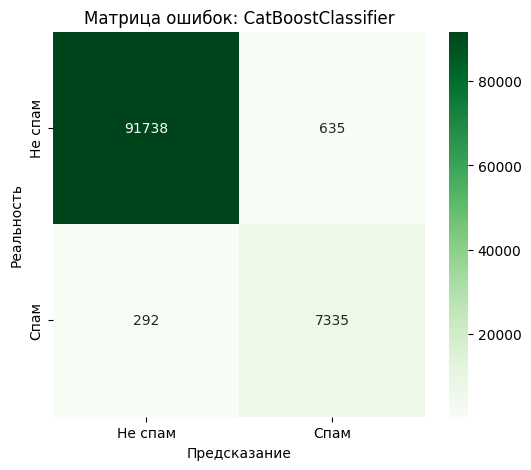

In [ ]:
cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Не спам', 'Спам'],
            yticklabels=['Не спам', 'Спам'])
plt.title('Матрица ошибок: CatBoostClassifier')
plt.xlabel('Предсказание')
plt.ylabel('Реальность')
plt.show()

# Анализ метрик, сравнение и выводы

| Метрика | CatBoost | Logistic Regression |
| :--- | :--- | :--- |
| **Precision:** | 0.92 | 0.89 |
| **Recall:** | 0.96 | 0.96 |
| **F1-Score:** | 0.94 | 0.92 |

Из таблицы следует, что Precision по сравнению с логистической регрессией вырос до 0.92, засчет чего F1-Score увеличился до 0.94.
На матрице ошибок видно, что модель показала значительное снижение ложноположительных срабатываний с 922 до 635 на тестовой выборке, однако, такое количество все еще остается высоким.   